In [ ]:
import mulink  # noqa F401 - automatically extends mudata
import networkx as nx
import anndata as ad
import pandas as pd
import numpy as np
import mudata as md

In [2]:
def to_anndata(df: pd.DataFrame) -> ad.AnnData:
    """Generate anndata object"""
    return ad.AnnData(
        X=df.values,
        obs=df.index.to_frame(index=False, name="obs").set_index("obs"),
        var=df.columns.to_frame(index=False, name="var").set_index("var"),
    )

In [ ]:
image = to_anndata(
    pd.DataFrame(
        np.random.random(size=(5, 3)),
        index=["cell-0", "cell-1", "cell-2", "cell-3", "cell-4"],
        columns=["dim-0", "dim-1", "dim-2"],
    )
)

rna = to_anndata(
    pd.DataFrame(
        np.random.random(size=(3, 6)),
        index=["obs-0__cell-0_cell-1", "obs-1__cell-2_cell-3", "obs-2__cell-4"],
        columns=["gene-0", "gene-1", "gene-2", "gene-3", "gene-4", "gene-5"],
    )
)

mdata = md.MuData(data={"image": image, "rna": rna})


# construct graph
observation_mapping = pd.DataFrame(
    {
        "image": ["cell-0", "cell-1", "cell-2", "cell-3", "cell-4"],
        "rna": [
            "obs-0__cell-0_cell-1",
            "obs-0__cell-0_cell-1",
            "obs-1__cell-2_cell-3",
            "obs-1__cell-2_cell-3",
            "obs-2__cell-4",
        ],
    }
)

dag = nx.from_pandas_edgelist(observation_mapping, source="image", target="rna", create_using=nx.DiGraph)
adjacency_matrix = pd.DataFrame.sparse.from_spmatrix(
    nx.adjacency_matrix(dag), index=dag.nodes(), columns=dag.nodes()
).reindex(index=mdata.obs_names, columns=mdata.obs_names)


# Currently, we need to specify axis + key in all operations
mdata.link.add_link(adjacency_matrix, axis=1, key="observation_mapping")

/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/lucas-diedrich/mamba/envs/mulink/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


<Axes: xlabel='Target', ylabel='Source'>

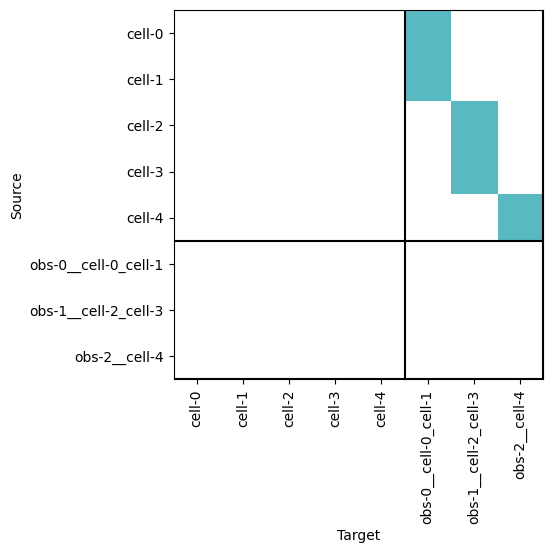

In [8]:
mdata.link.pl.adjacency_matrix(key="observation_mapping", axis=1, label=True, mod_limits=True)

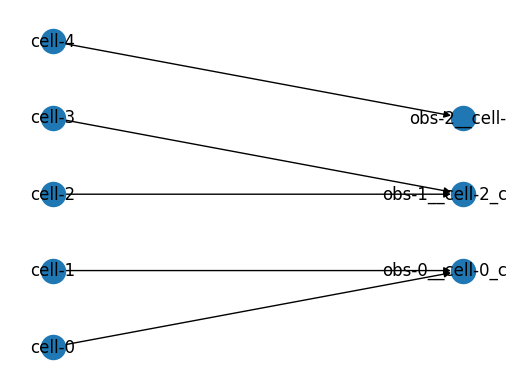

In [7]:
mdata.link.pl.graph(key="observation_mapping", axis=1, with_labels=True)

In [15]:
subset = mdata.link.query_descendants("cell-4", key="observation_mapping", axis=1)
subset.mod["rna"]

View of AnnData object with n_obs × n_vars = 1 × 6